# Compressive Sensing in MR
In this notebook, you'll see how it will be possible to reconstruct an MR from very strongly undersampled data.
The key, again, will be to find a representation in which the data are sparse. <br>
We suggest using **wavelets**: read a summary about them on Wiki <br>


Load the usual MR

(-0.5, 239.5, 239.5, -0.5)

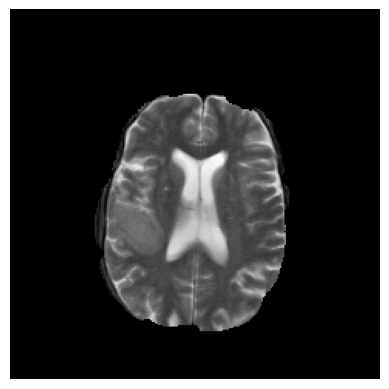

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
refImm = np.load('testMR.npy')
plt.imshow(refImm,cmap='gray')
plt.axis('off')

## Show how Wavelets works
In the first cell I will show how to call the wavelet transform.
<br>Then I'll provide a function to show the wavelet decomposition
<br> Finally, how a decomposed image looks like at every "level"

In [2]:
import pywt
coeffs = pywt.wavedec2(refImm, wavelet='db4', level=3)

In [3]:
import matplotlib.pyplot as plt

def plot_wavedec2_coeffs(coeffs, cmap='gray'):
    """
    coeffs: output of pywt.wavedec2(image, wavelet, level=N)
    """
    cA = coeffs[0]
    details = coeffs[1:]  # list of (cH, cV, cD)

    n_levels = len(details)

    fig, axes = plt.subplots(n_levels + 1, 4, figsize=(12, 3*(n_levels+1)))
    
    # First row: approximation
    axes[0, 0].imshow(cA, cmap=cmap)
    axes[0, 0].set_title("Approximation A")
    axes[0, 1].axis("off")
    axes[0, 2].axis("off")
    axes[0, 3].axis("off")

    # Detail rows
    for i, (cH, cV, cD) in enumerate(details, start=1):
        level = n_levels - i + 1  # highest level first
        cm = cH.mean()-1.5*cH.std()
        cM = cH.mean()+1.5*cH.std()
        axes[i, 0].imshow(cH, cmap=cmap,vmin=cm,vmax=cM)
        axes[i, 0].set_title(f"Level {level} – Horizontal H")
        cm = cH.mean()-1.5*cV.std()
        cM = cH.mean()+1.5*cV.std()
        axes[i, 1].imshow(cV, cmap=cmap,vmin=cm,vmax=cM)
        axes[i, 1].set_title(f"Level {level} – Vertical V")
        cm = cD.mean()-1.5*cV.std()
        cM = cD.mean()+1.5*cV.std()
        axes[i, 2].imshow(cD, cmap=cmap,vmin=cm,vmax=cM)
        axes[i, 2].set_title(f"Level {level} – Diagonal D")

        axes[i, 3].axis("off")

    for axrow in axes:
        for ax in axrow:
            ax.set_xticks([])
            ax.set_yticks([])

    plt.tight_layout()
    plt.show()


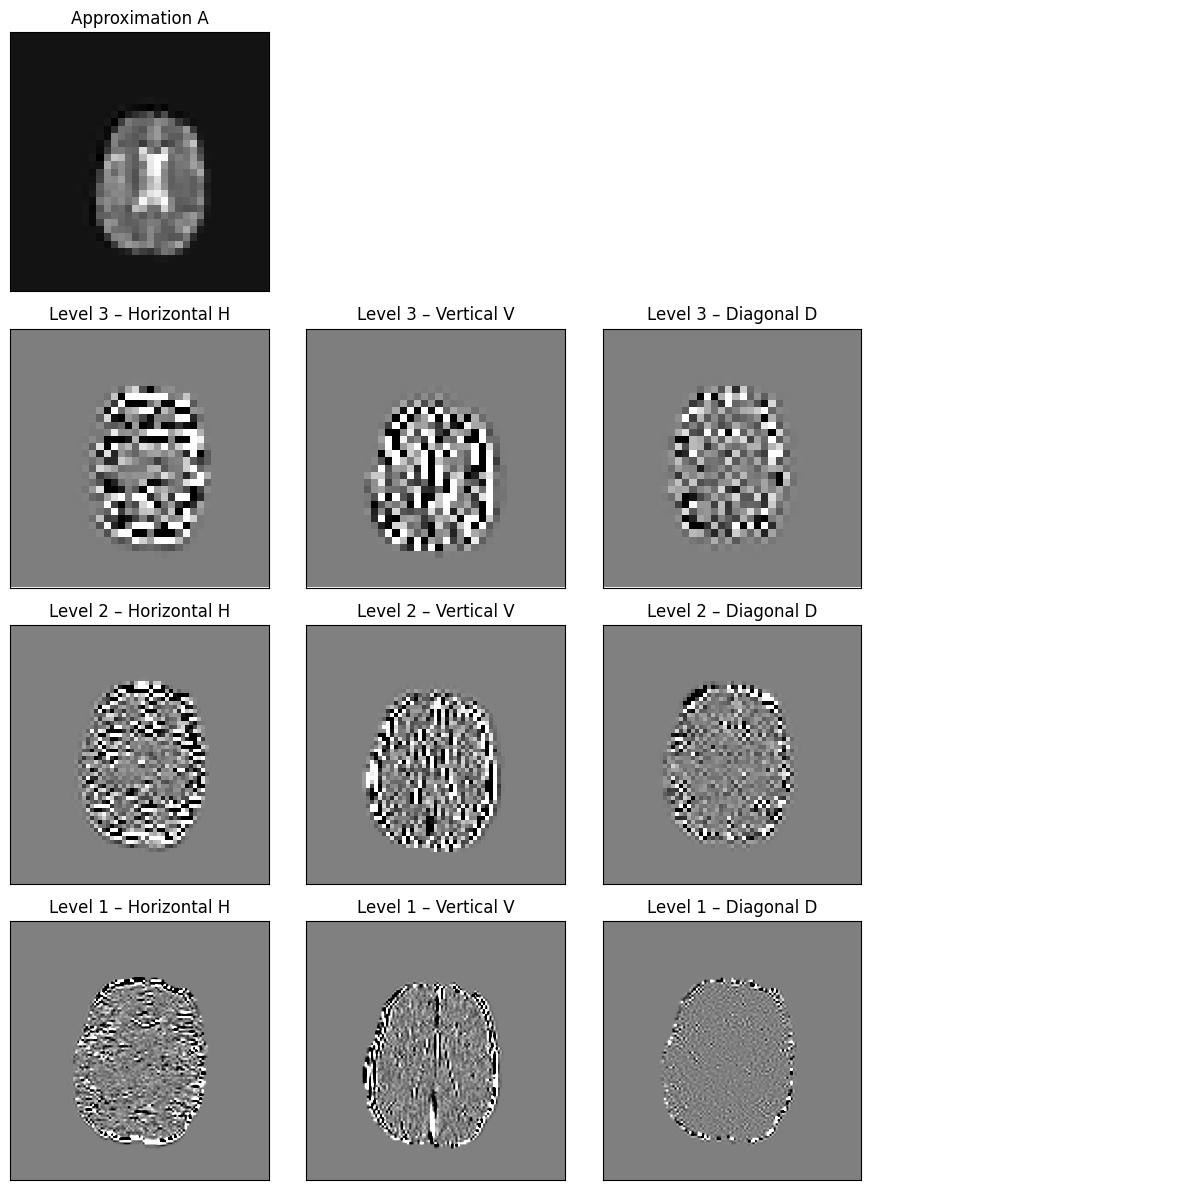

In [4]:

plot_wavedec2_coeffs(coeffs)


## Show that noise instead is not sparse in the wavelet basis

In [ ]:
noisyImm = refImm + np.random.normal(0,.03,refImm.shape)
coeffs = pywt.wavedec2(noisyImm, wavelet='db4', level=3)
plt.imshow(noisyImm,vmin=.1,vmax=.9)
plt.xlim(50,150)
plt.ylim(150,50)

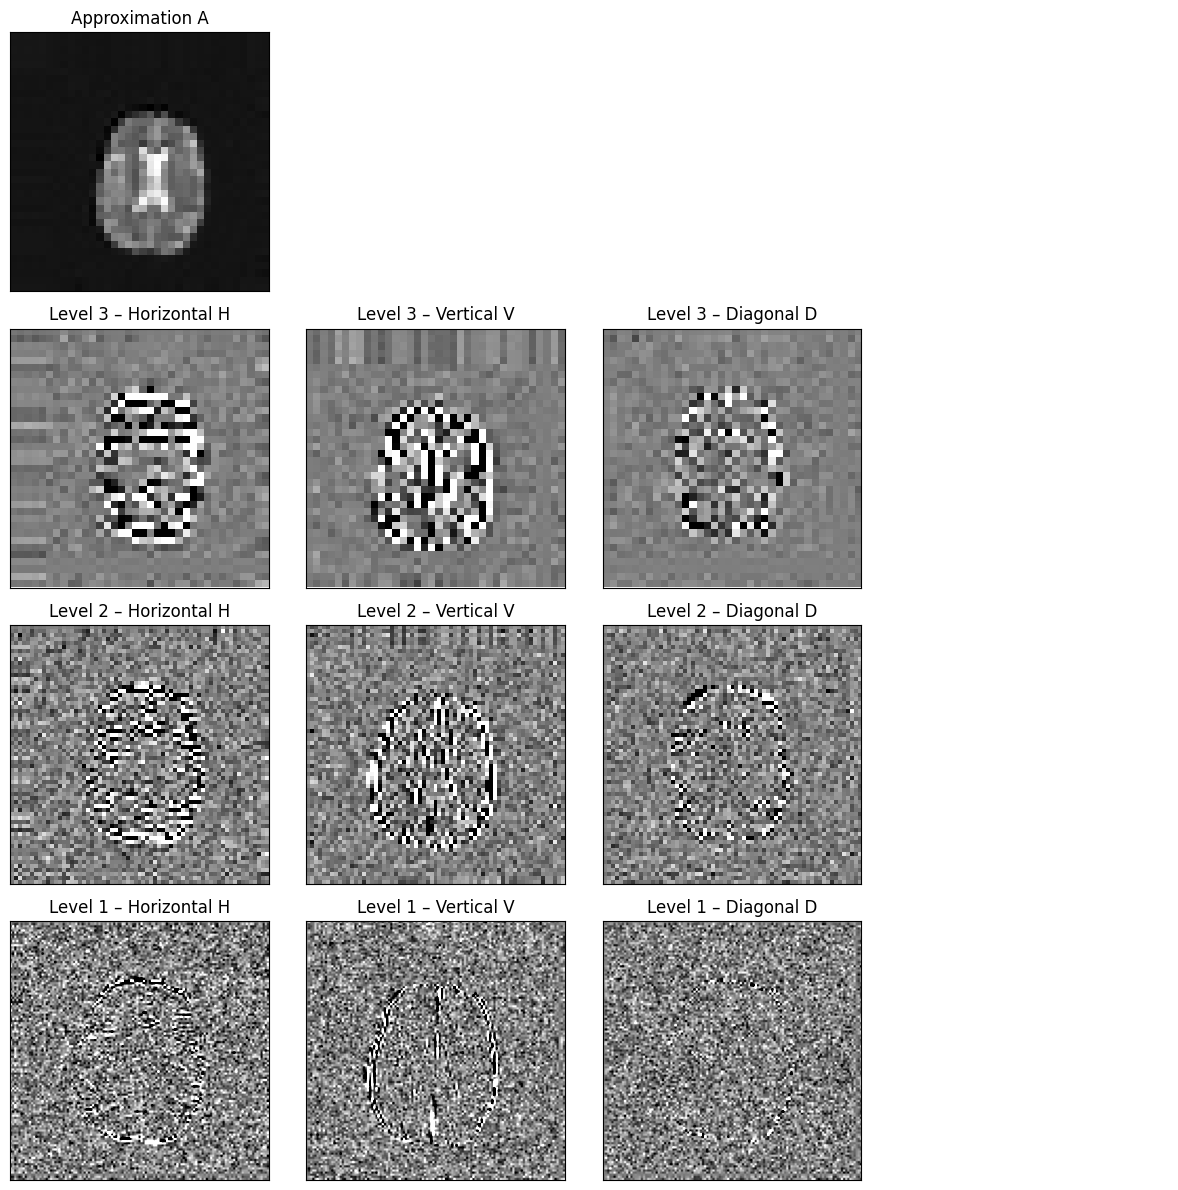

In [7]:
plot_wavedec2_coeffs(coeffs)


# Task 1: Implement ISTA using wavelets
ISTA works like this:
1. Image gradient: current image estimate + $\alpha$ gradient ($F^{-1} M[Fx-y]$)
2. Soft thresholding: image -> wavelet transform -> soft thresholding -> anti-transform

In Math:
* Take some $x^0$, define the residual $r= M\left[Fx^0 -y\right]$
* $g^{k+1} = F^-1  M\left[ Fx^k -y\right]$
* $x^{k+0.5} = x^k -\tau g$
* $ w = Wx^{k+0.5}$
* $ w = \operatorname{sign}(w)\,\max(|w|-\tau \beta,0)$
* $ x^{k+1} = W^{-1} w $


Now copy the subsampling functions from the previous notebook (or move them to a .py file from which to import), and test ISTA over them, as instructed in the manual